# Import Libraries

In [19]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [20]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Convert Date

In [21]:

df['Order Date'] = pd.to_datetime(df['Order Date'])


# ==============================
# KPI VALUES
# ==============================


In [22]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_discount = df['Discount'].mean() * 100

print("========== BUSINESS KPIs ==========")
print(f"Total Sales   : ${total_sales:,.2f}")
print(f"Total Profit  : ${total_profit:,.2f}")
print(f"Total Orders  : {total_orders}")
print(f"Avg Discount  : {avg_discount:.2f}%")

========== BUSINESS KPIs ==========
Total Sales   : $2,297,200.86
Total Profit  : $286,397.02
Total Orders  : 5009
Avg Discount  : 15.62%


# ==============================
# SALES BY CATEGORY
# ==============================


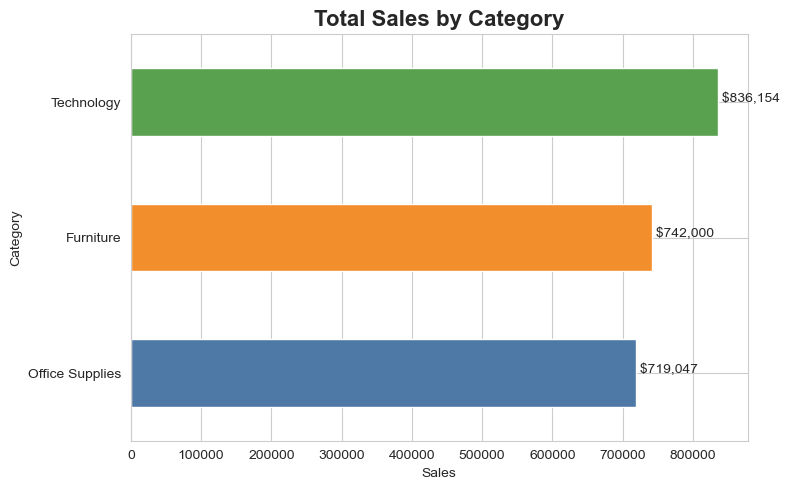

In [23]:

plt.figure(figsize=(8,5))

category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(
    kind='barh',
    color=['#4E79A7', '#F28E2B', '#59A14F']
)

plt.title("Total Sales by Category", fontsize=16, weight='bold')
plt.xlabel("Sales")
plt.ylabel("Category")

for index, value in enumerate(category_sales):
    plt.text(value, index, f' ${value:,.0f}')

plt.tight_layout()
plt.show()

# ==============================
# PROFIT BY REGION
# ==============================

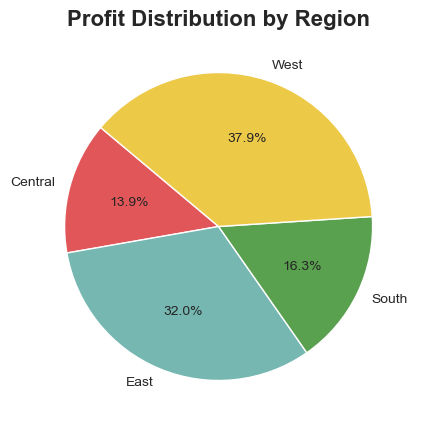

In [24]:
plt.figure(figsize=(8,5))

region_profit = df.groupby('Region')['Profit'].sum()

colors = ['#E15759', '#76B7B2', '#59A14F', '#EDC948']

plt.pie(
    region_profit,
    labels=region_profit.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title("Profit Distribution by Region", fontsize=16, weight='bold')

plt.show()

# ==============================
# MONTHLY SALES TREND
# ==============================

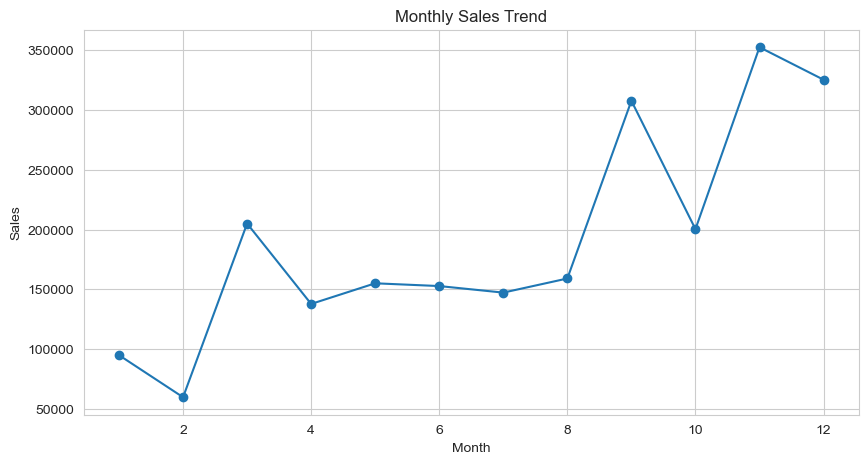

In [25]:
monthly_sales = df.groupby(
    df['Order Date'].dt.month
)['Sales'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()


# ==============================
# TOP 10 SUB-CATEGORIES
# ==============================

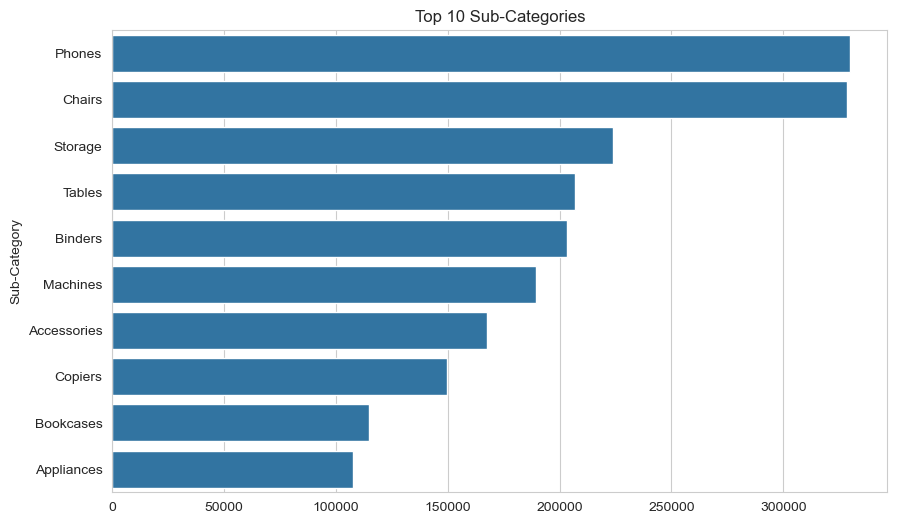

In [26]:
top_sub = df.groupby('Sub-Category')['Sales'].sum() \
            .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sub.values,
    y=top_sub.index
)

plt.title("Top 10 Sub-Categories")

plt.show()

# ==============================
# CORRELATION HEATMAP
# ==============================


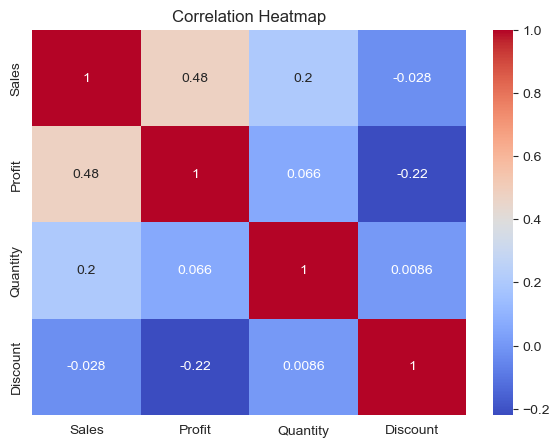

Dashboard Visualization Completed Successfully!


In [27]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df[['Sales', 'Profit', 'Quantity', 'Discount']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show() 
print("Dashboard Visualization Completed Successfully!")